In [169]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import distance
from operator import itemgetter
from sklearn.neighbors import NearestNeighbors, KDTree
import time
import imageio
import os

In [170]:
df = pd.read_csv('./iris.csv')
cols = df.columns[:-1]

In [171]:
# https://www.geeksforgeeks.org/calculate-the-euclidean-distance-using-numpy/
def euclidean(x1, x2):
    return distance.euclidean(x1, x2)

def chebychev(x1, x2):
    return distance.chebyshev(x1, x2)

def manhattan(x1, x2):
    return distance.cityblock(x1, x2)

In [172]:
colors = ['gray', 'orange', 'r', 'g', 'b', 'c', 'm', 'y', 'k', 'w']
t1 = ('petal.width', 'petal.length')
t2 = ('petal.length', 'sepal.width')
t3 = ('sepal.length', 'petal.width')

In [173]:
# https://neptune.ai/blog/k-means-clustering
def rand_centroids(data, k, distance):
    r, c = data.shape
    c_idx = np.random.choice(r, k)
    return data.iloc[c_idx].to_numpy()

def plus_plus(data, k, distance):
    centroids = [ data.sample(n=1).to_numpy().tolist()[0] ]
    for _ in range(k-1):
        new_c = ([],-1)         # centroid, distance to c
        for i in range(len(data)):
            x_i = data.iloc[i].to_numpy().tolist()
            if x_i not in centroids:
                d = 0
                for c in centroids:
                    d += pow(distance(c, x_i), 2)
                d /= len(centroids)
                new_c = (x_i, d) if new_c[1] < d else new_c
        centroids.append(new_c[0])
    return np.matrix(centroids)    

In [174]:
class Mean_Shift():
    def __init__(self, data, n, distance=euclidean, cc=rand_centroids, m='euclidean'):
        self.data = d
        self.n = n          # n° centroids
        self.K = None
        self.KDT = KDTree(self.data.to_numpy(), metric=m)
        self.d = distance
        self.cc = cc        # centroid criteria
        self.e = 1.2
    
    def region_query(self, k):
        N = self.KDT.query_radius([k], r=self.e)[0]
        return self.data.iloc[N].to_numpy()
    
    def move(self, kernel):
        neighbors = self.region_query(kernel)
        return np.mean(neighbors, axis=0)

    def run(self):
        new_K = np.unique(self.cc(self.data, 10*self.n, self.d), axis=0)
        self.save_plot(t1, new_K, 'y')
        prev_K = None
        while len(new_K) > self.n:
            prev_K = new_K
            idx = 0
            for kernel in new_K:
                new_K[idx] = self.move(kernel)
                idx += 1
            # print(new_K)
            new_K = np.unique(new_K, axis=0)
            self.save_plot(t1, new_K, 'r')
            self.save_plot(t2, new_K, 'b')
            self.save_plot(t3, new_K, 'g')
            if new_K.shape == prev_K.shape:
                if not (new_K != prev_K).any():
                    break
        return new_K

    def save_plot(self, xy, kernels, col):
        k = pd.DataFrame(kernels, columns=self.data.columns)
        x, y = xy

        plt.clf()
        plt.scatter(self.data[x], self.data[y], c='gray')
        plt.scatter(k[x], k[y], c=col)
        plt.show()


In [175]:
K = 3
data = df.copy()
d = data.iloc[:,:-1]

In [176]:
ms = Mean_Shift(data=d, n=K, cc=plus_plus)

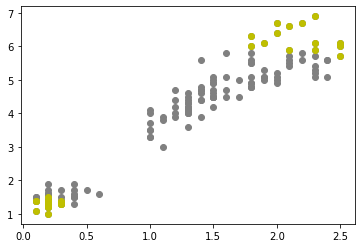

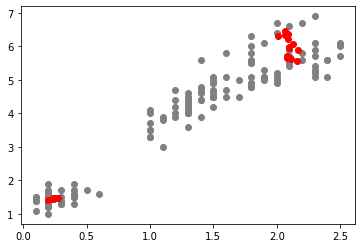

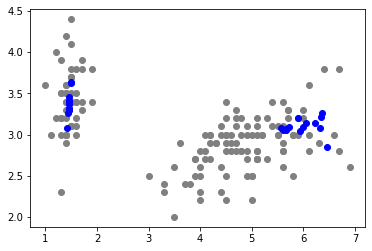

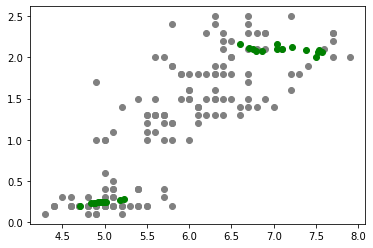

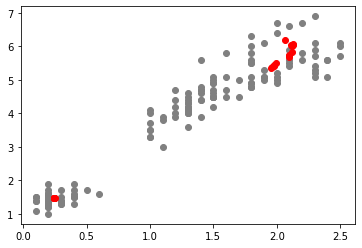

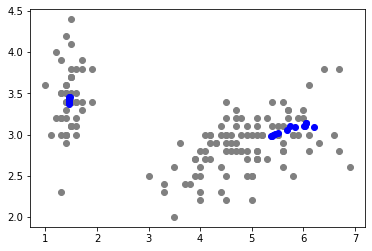

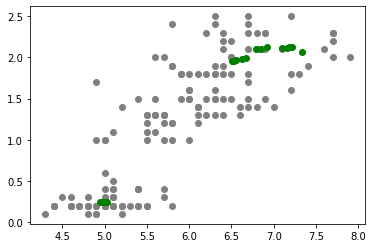

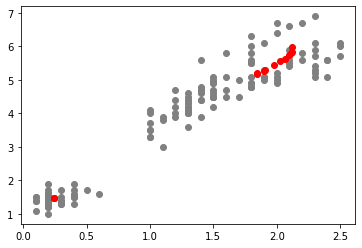

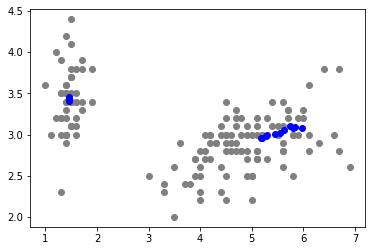

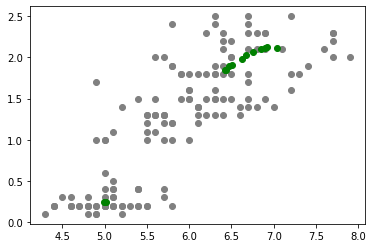

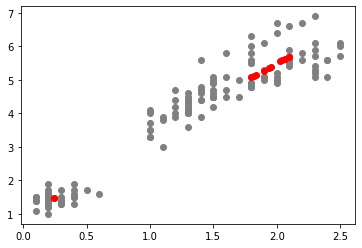

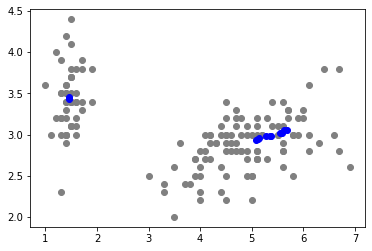

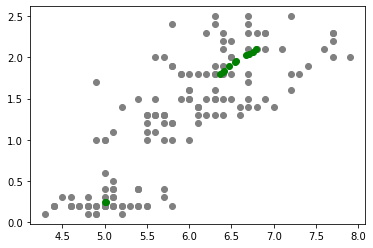

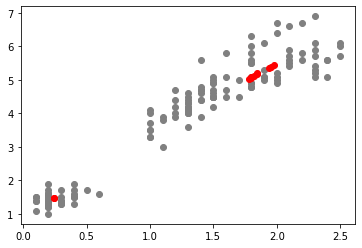

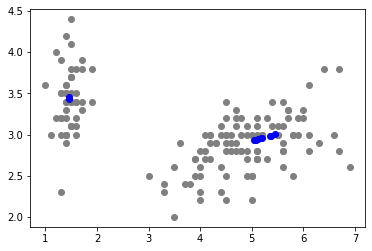

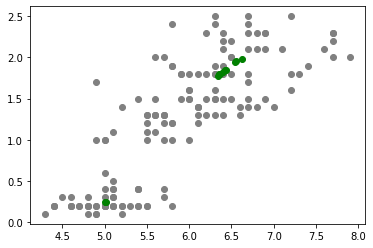

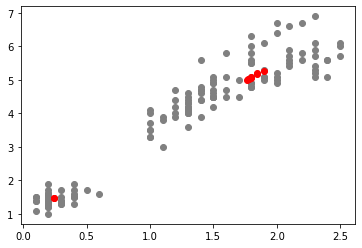

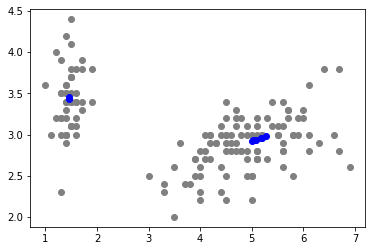

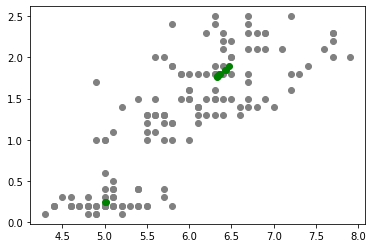

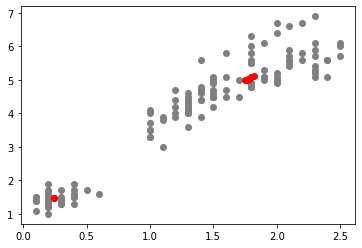

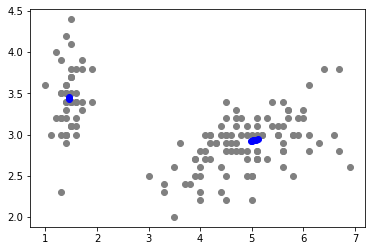

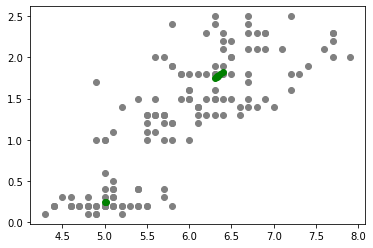

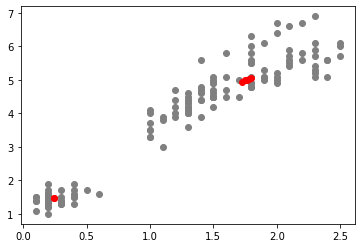

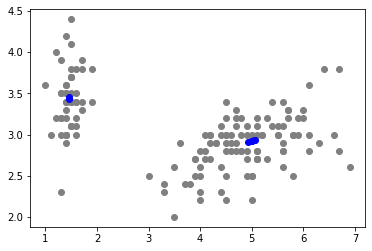

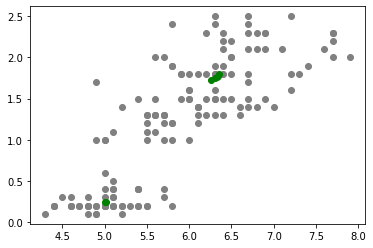

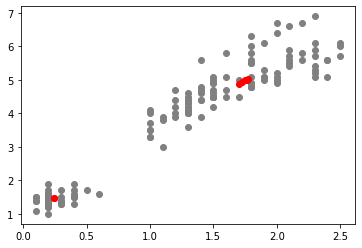

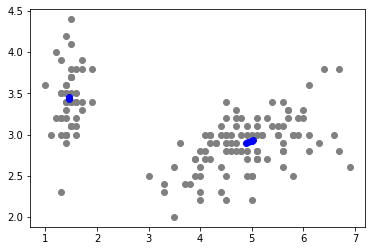

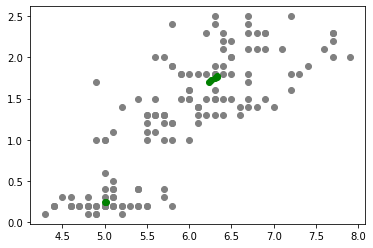

array([[5.00208333, 3.43125   , 1.46458333, 0.24166667],
       [5.01632653, 3.45102041, 1.46530612, 0.24489796],
       [6.23333333, 2.90289855, 4.88985507, 1.69855072],
       [6.25588235, 2.91176471, 4.92647059, 1.72352941],
       [6.30746269, 2.92686567, 4.98507463, 1.75074627],
       [6.32835821, 2.92686567, 5.01044776, 1.7641791 ],
       [6.33181818, 2.92878788, 5.02575758, 1.77121212]])

In [177]:
ms.run()

In [178]:
n1 = np.array([[1, 2], [3, 4]])
n2 = np.array([[5, 6], [3, 4]])

print((n1 == n2).all())
print(n1 != n2)

False
[[ True  True]
 [False False]]
